# Analyzing Open Problems results in a smaller scope

- Using the newest run (2025.10.11) results
- 10 Datasets
    - mouse pancreas atlas
    - diabetic kidney disease
    - immune cell atlas
    - gtex_vg
    - hypomap
    - tabula sapiens
    - zebrafish
    - cengen
    - human immune (immune_cells: from scib benchmark)
    - human pancreas (pancreas: from scib benchmark)
    
  including following dataset features:
    - organism
    - n_tissues
    - size
    - n_genes
    - n_celltypes
    - n_batches
    - batch_imbalance (Coeffiecient of Variance)
    - nested_batch
    - n_donors
    - n_samples
- The metric `kBET` will be excluded since it fails when running on mouse pancreas atlas
- `HVG overlap` will be excluded as it is only computed for very few methods
- Methods that fail often or consistantly perform poorly are excluded (below (and including) BBKNN)

## setting up the packages and dataframe

In [69]:
import os
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import time
import seaborn as sns  # optional, just for color if you like
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.linear_model import LinearRegression
import numpy as np


In [23]:
base_dir = "/Users/seohyon/resources/results"

# will track only these methods (above BBKNN)
keep_methods = [
    "embed_cell_types_jittered",
    "embed_cell_types",
    "shuffle_integration",
    "scanvi",
    "combat",
    "scvi",
    "harmony",
    "harmonypy",
    "batchelor_fastmnn",
    "liger",
    "pyliger",
    "scalex",
    "uce",
    "no_integration",
    "no_integration_batch",
]

rows = []

# Step 1 — Collect all rows
for folder in os.listdir(base_dir):
    folder_path = os.path.join(base_dir, folder)
    yaml_path = os.path.join(folder_path, "score_uns.yaml")
    
    if os.path.isdir(folder_path) and os.path.exists(yaml_path):
        with open(yaml_path, "r") as f:
            try:
                data = yaml.safe_load(f)
            except yaml.YAMLError as e:
                print(f"⚠️ Could not read {yaml_path}: {e}")
                continue

        for entry in data:
            method = entry.get("method_id", "").strip().lower()

            # ✅ keep only methods in your whitelist
            if method not in keep_methods:
                continue

            metrics = entry.get("metric_ids", [])
            values = entry.get("metric_values", [])

            for m_id, m_val in zip(metrics, values):
                rows.append({
                    "dataset_id": entry.get("dataset_id"),
                    # "file_size": entry.get("file_size"),
                    "method_id": method,
                    # "normalization_id": entry.get("normalization_id"),
                    "metric_id": m_id,
                    "metric_value": m_val
                })

In [77]:
# Step 2 — Create one big DataFrame
df = pd.DataFrame(rows)
df = df.dropna(subset=["metric_value"]).copy() # drop NaN
df = df[df["metric_id"] != "kbet"].copy() # drop kbet
df["dataset_id"] = df["dataset_id"].str.split("/").str[-1] # clean the dataset id

# # Step 3 — Split into separate tables per dataset_id
# datasets = {}
# for dataset_id, sub_df in df.groupby("dataset_id"):
#     datasets[dataset_id] = sub_df.reset_index(drop=True)
#     print(f"\n=== Dataset: {dataset_id} ===")
#     print(sub_df)

In [78]:
# adding dataset metadata to the dataframe
meta = pd.read_csv("/Users/seohyon/resources/Batch_Integration_Dataset - Tabellenblatt3.csv")

df = pd.merge(df, meta, left_on="dataset_id", right_on="dataset", how="inner").drop(columns=["dataset"])

In [79]:
df["metric_id"].unique()

array(['graph_connectivity', 'ari', 'nmi', 'cell_cycle_conservation',
       'pcr', 'hvg_overlap', 'ilisi', 'clisi', 'asw_label',
       'isolated_label_f1', 'asw_batch', 'isolated_label_asw', 'kbet_pg',
       'kbet_pg_label', 'ari_batch', 'nmi_batch'], dtype=object)

In [80]:
# control methods - flags
control_type_map = {
    "embed_cell_types": "positive",
    "embed_cell_types_jittered": "positive",
    "shuffle_integration": "negative",
    "shuffle_integration_by_batch": "negative",
    "shuffle_integration_by_cell_type": "negative",
    "no_integration": "baseline",
    "no_integration_batch": "baseline",
}

df["control_type"] = df["method_id"].map(control_type_map).fillna("none") # none for non-control methods

Sub-dataframe per metric for plotting:

In [47]:
for metric in metrics:
    globals()[f"df_{metric}"] = df[df["metric_id"] == metric].sort_values("size")

## Correlation between one metric and one feature (per method)

- plot a line plot and if you see a linear trend: sklearn linear regression
- take one postive control method, one negative, and one integration method that I understand so that I have an expectation
    - scvi, harmony, scanorama
- random effect: method
- if I don’t see a linear trend: move on to the next metric; maybe there’s a way to see them all at once as well idk
- if the method is a control method, the line is coloured orange, if not, blue

### for size

### ari vs size - no linear relationship

maybe do scatter and seaborn regression

put these together in one plot and distinguish left and right control non control (line plots on multiple facets)

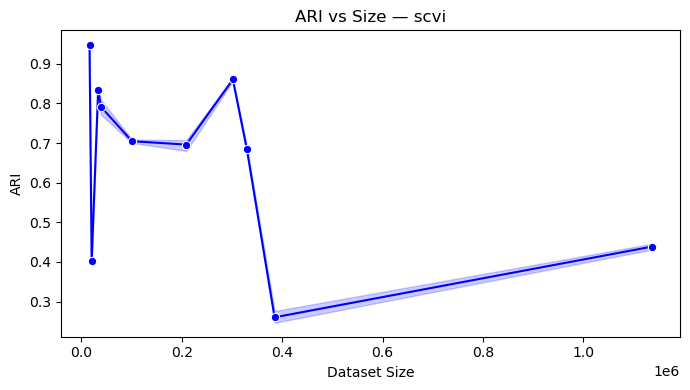

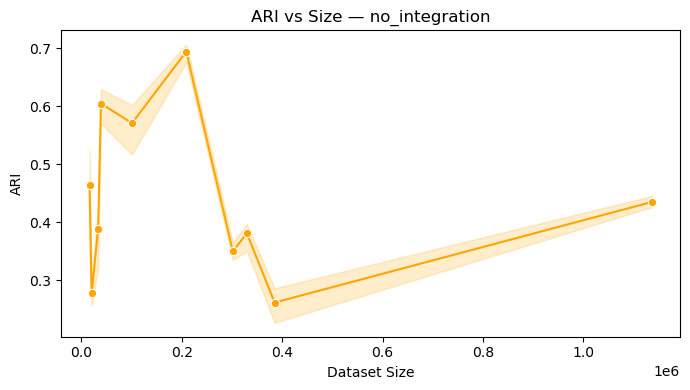

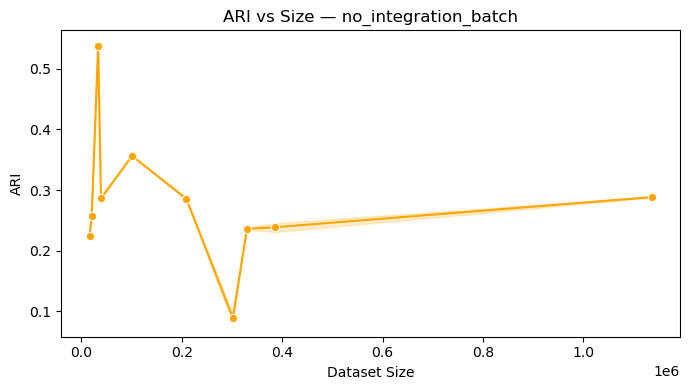

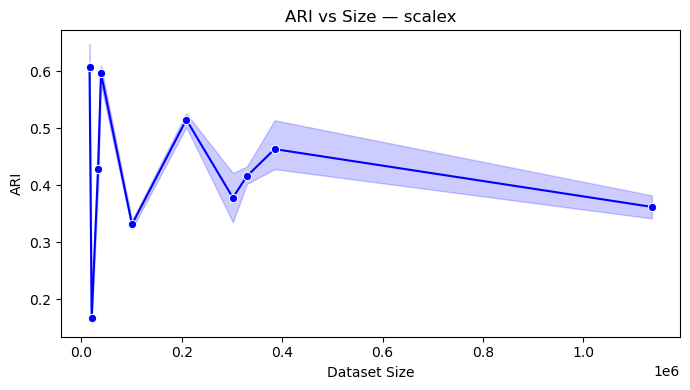

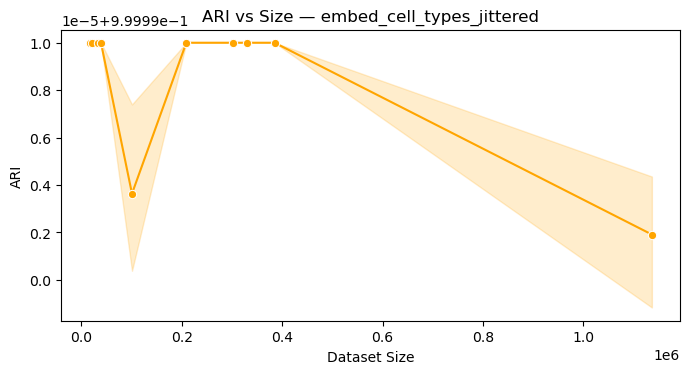

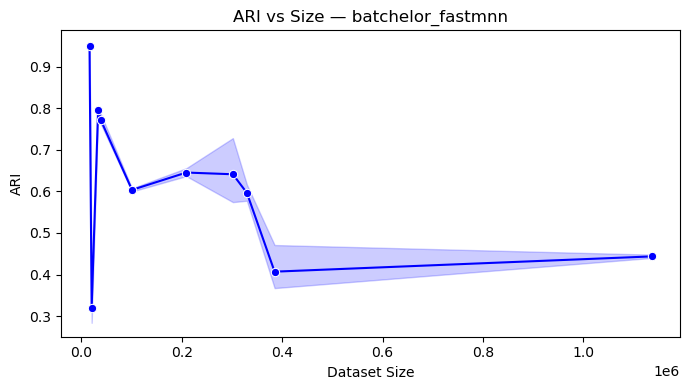

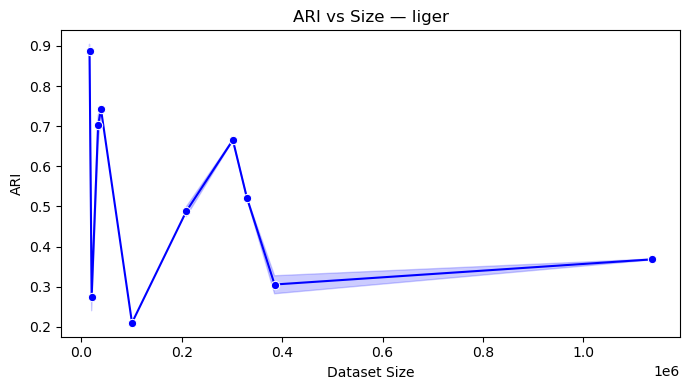

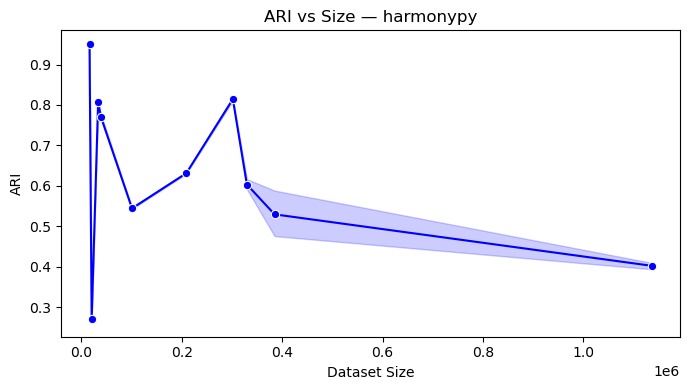

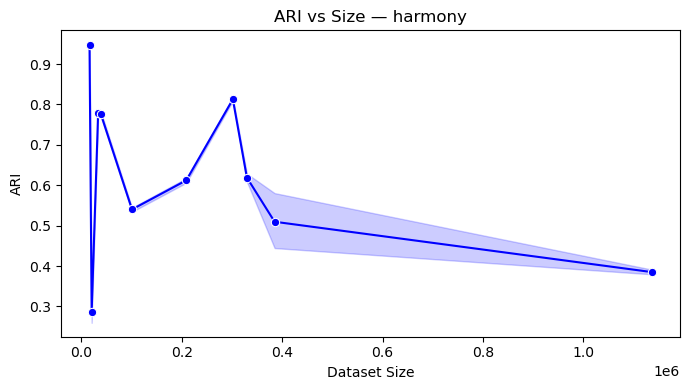

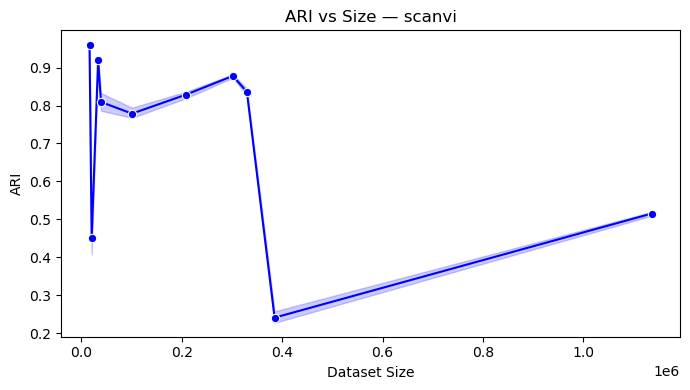

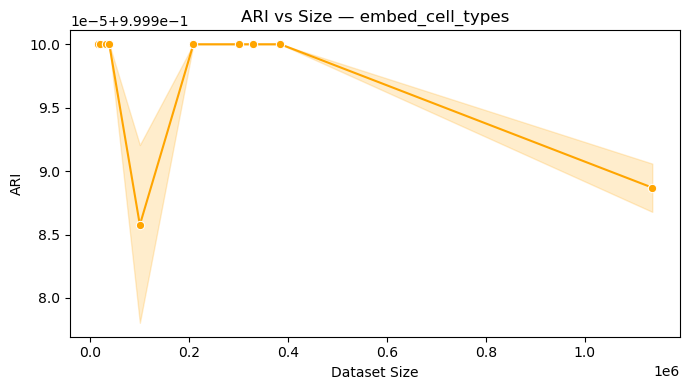

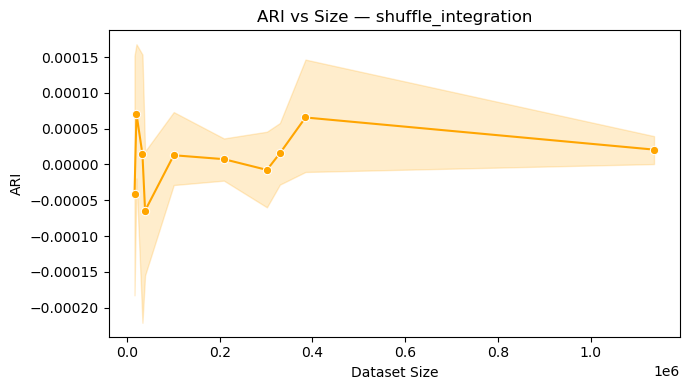

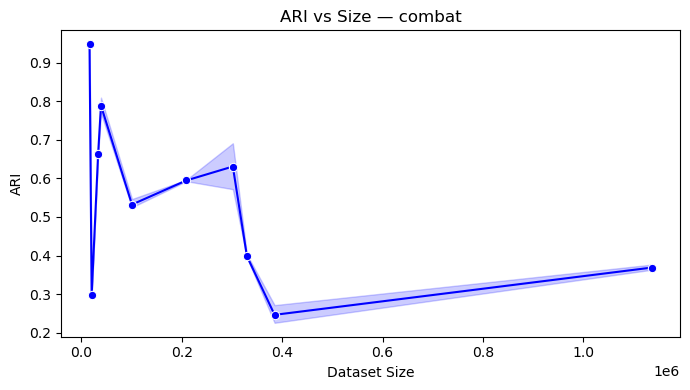

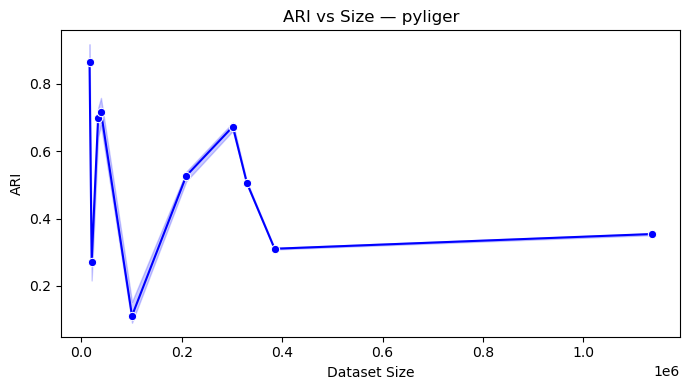

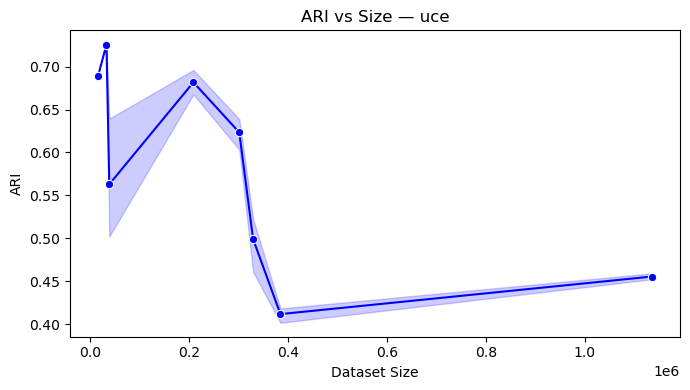

In [75]:
for method in df["method_id"].unique():
    df_m = df_ari[df_ari["method_id"] == method].sort_values("size")
    
    # Decide color: orange if control, blue if not
    is_control = df_m["control_type"].notna().any() and (df_m["control_type"] != "none").any()
    color = "orange" if is_control else "blue"
    
    plt.figure(figsize=(7, 4))
    sns.lineplot(
        data=df_m,
        x="size",
        y="metric_value",
        marker="o",
        color=color,
        errorbar=None, # confidence interval
    )
    
    # force the y-axis scale to be 0 to 1
    
    plt.title(f"ARI vs Size — {method}")
    plt.xlabel("Dataset Size")
    plt.ylabel("ARI")
    plt.tight_layout()
    plt.show()

### ari vs n_genes - uce

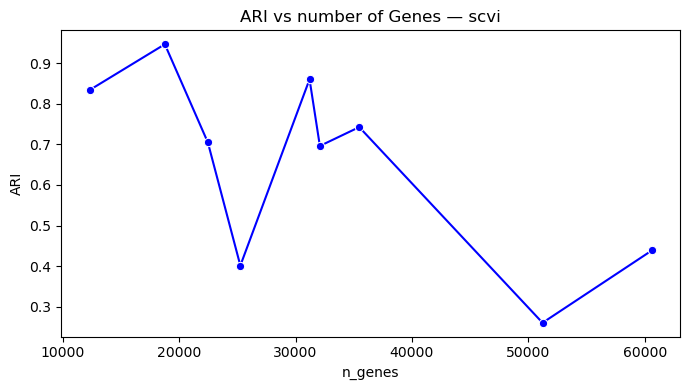

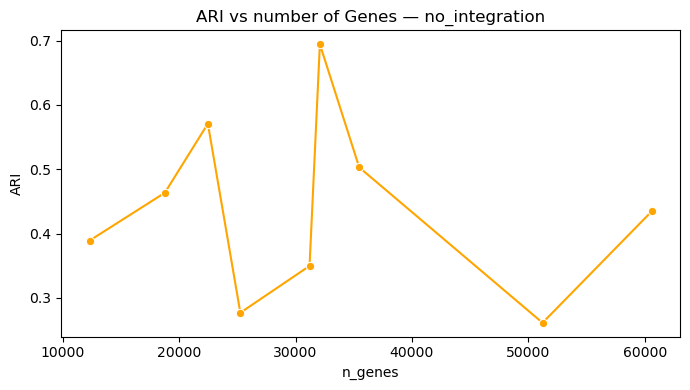

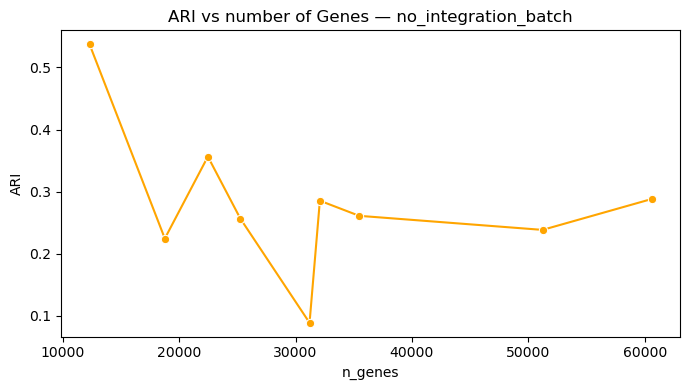

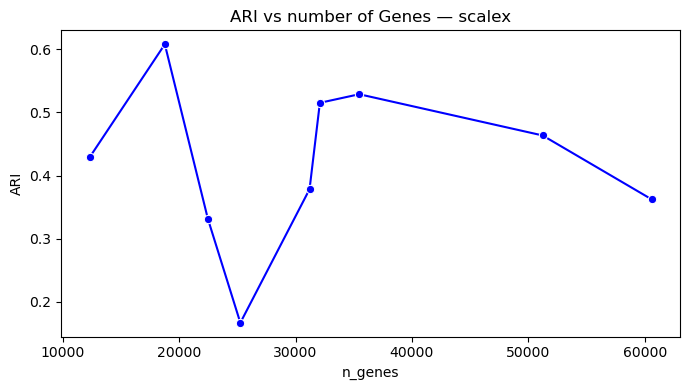

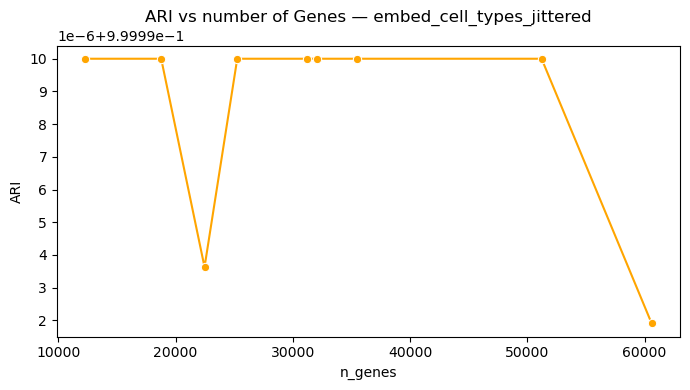

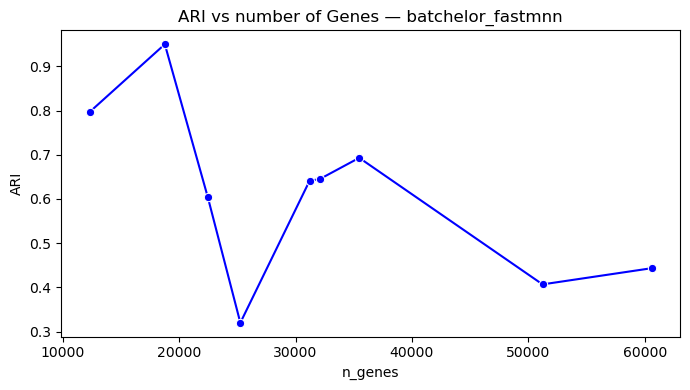

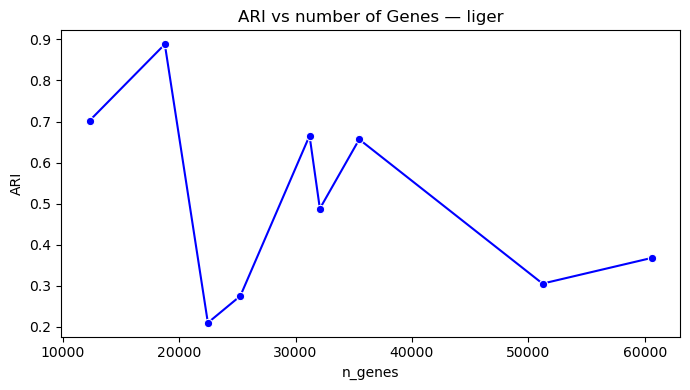

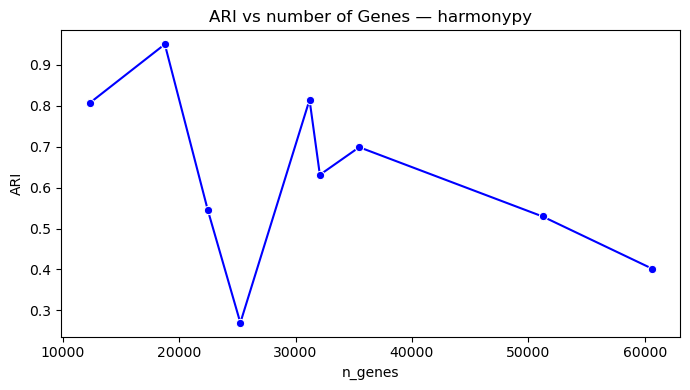

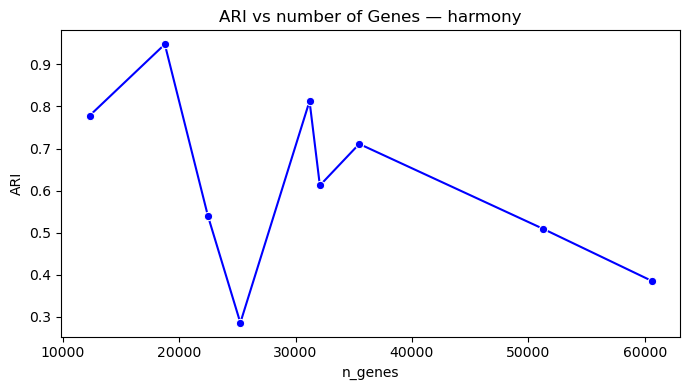

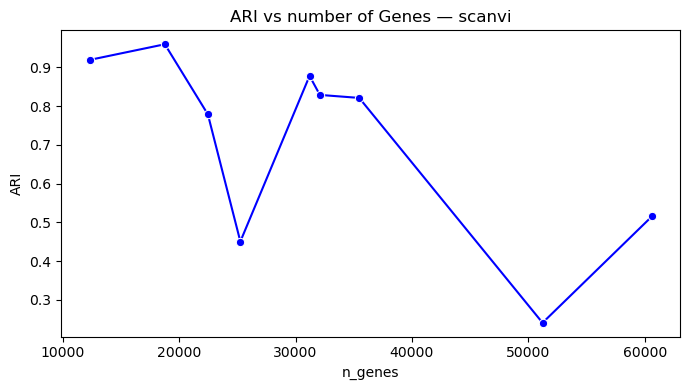

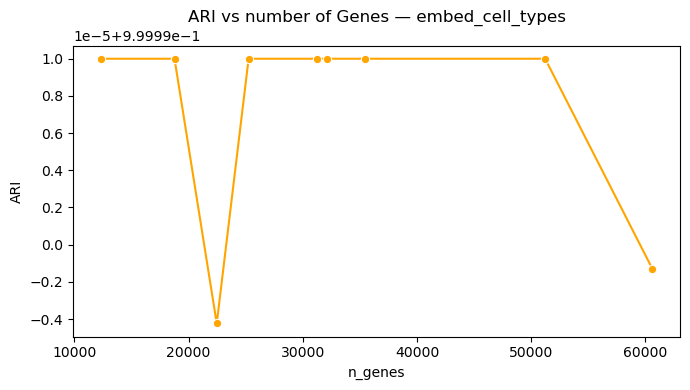

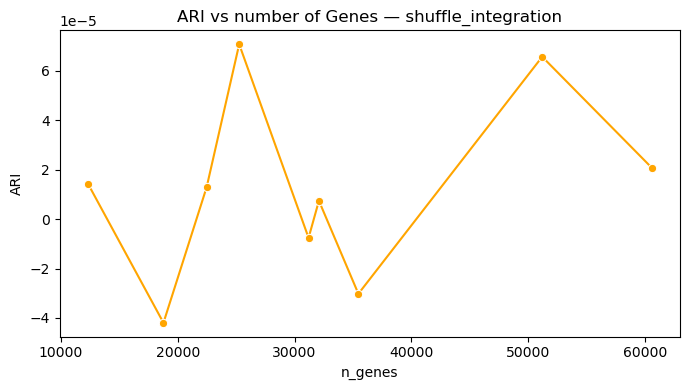

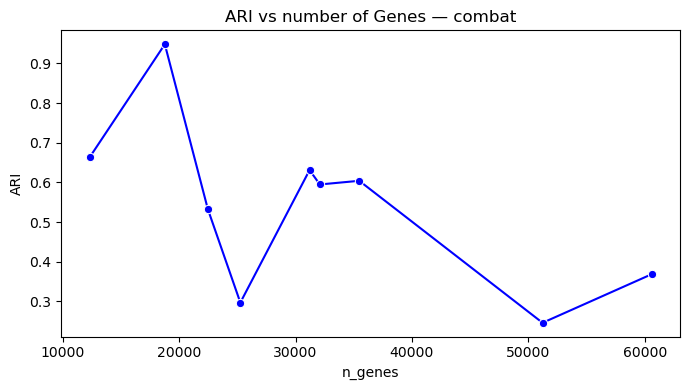

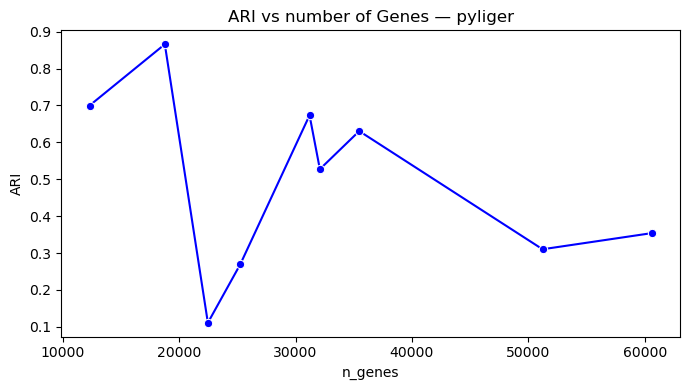

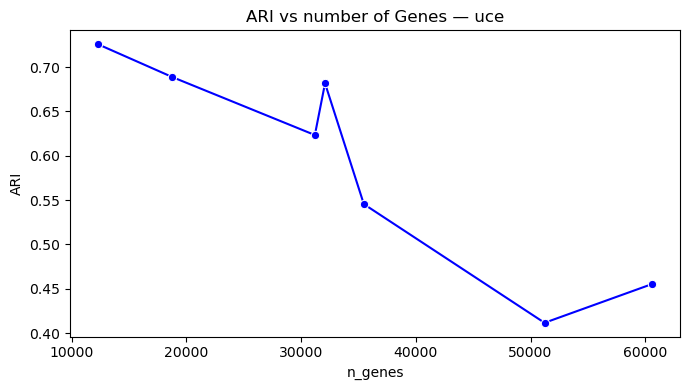

In [62]:
for method in df["method_id"].unique():
    df_m = df_ari[df_ari["method_id"] == method].sort_values("size")
    
    # Decide color: orange if control, blue if not
    is_control = df_m["control_type"].notna().any() and (df_m["control_type"] != "none").any()
    color = "orange" if is_control else "blue"
    
    plt.figure(figsize=(7, 4))
    sns.lineplot(
        data=df_m,
        x="n_genes",
        y="metric_value",
        marker="o",
        color=color,
        errorbar=None, # confidence interval
    )
    
    plt.title(f"ARI vs number of Genes — {method}")
    plt.xlabel("n_genes")
    plt.ylabel("ARI")
    plt.tight_layout()
    plt.show()

Spotted a linear relationship: uce

*Idea*: what if I just plot everything in spearman correlation and see which pair would have a monotonous relationship, instead of plotting the line plot for each of them? => good idea

In [74]:
df_ari.query("method_id == 'uce'")

,dataset_id,method_id,metric_id,metric_value,organism,n_tissues,size,n_genes,n_celltypes,n_batches,batch_imbalance,nested_batches,n_samples,n_donors,control_type
5893,pancreas,uce,ari,0.688882,Human,NaN,16382,18771,14,9,0.46,NaN,49.0,49.0,none
10064,immune_cells,uce,ari,0.726151,Human,2.0,33506,12303,16,10,0.77,Yes,5.0,10.0,none
4959,immune_cells,uce,ari,0.725530,Human,2.0,33506,12303,16,10,0.77,Yes,5.0,10.0,none
8308,dkd,uce,ari,0.501068,Human,1.0,39176,35469,13,11,0.54,No,11.0,11.0,none
2881,dkd,uce,ari,0.507962,Human,1.0,39176,35469,13,11,0.54,No,11.0,11.0,none
8961,dkd,uce,ari,0.806999,Human,1.0,39176,35469,13,11,0.54,No,11.0,11.0,none
7231,dkd,uce,ari,0.502141,Human,1.0,39176,35469,13,11,0.54,No,11.0,11.0,none
10239,dkd,uce,ari,0.504195,Human,1.0,39176,35469,13,11,0.54,No,11.0,11.0,none
4573,dkd,uce,ari,0.501003,Human,1.0,39176,35469,13,11,0.54,No,11.0,11.0,none
11017,dkd,uce,ari,0.500792,Human,1.0,39176,35469,13,11,0.54,No,11.0,11.0,none


In [67]:
# helper function
def spearman_by_method(df_metric, feature, plot=True, palette="viridis"):
    correlations = []

    for method in df_metric["method_id"].unique():
        df_m = df_metric[df_metric["method_id"] == method]

        if len(df_m) < 2:
            continue

        rho, pval = spearmanr(df_m[feature], df_m["metric_value"])

        correlations.append({
            "method": method,
            "spearman_rho": rho,
            "p_value": pval,
            "n_points": len(df_m),
        })

    corr_df = pd.DataFrame(correlations).sort_values("spearman_rho", ascending=False)

    # ---------- PLOT ----------
    if plot and not corr_df.empty:
        plt.figure(figsize=(10, 6))
        sns.barplot(
            data=corr_df,
            x="spearman_rho",
            y="method",
            orient="h",
        )
        plt.axvline(0, color="black", linewidth=1)
        plt.title(f"Spearman correlation: metric_value vs {feature}")
        plt.xlabel("Spearman ρ")
        plt.ylabel("Method")
        plt.tight_layout()
        plt.show()

    return corr_df

color control and non control method

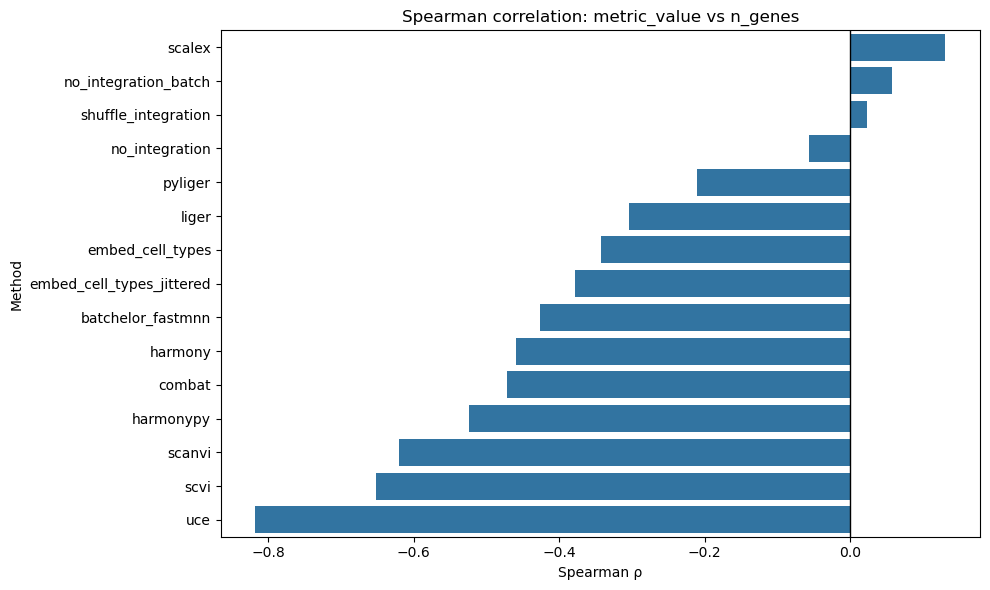

,method,spearman_rho,p_value,n_points
12,scalex,0.131273,3.348553e-01,56
4,no_integration_batch,0.058314,5.960306e-01,85
10,shuffle_integration,0.022996,8.416070e-01,78
5,no_integration,-0.056833,6.054097e-01,85
11,pyliger,-0.210105,9.298437e-02,65
0,liger,-0.303999,1.459972e-02,64
6,embed_cell_types,-0.342649,1.420038e-03,84
7,embed_cell_types_jittered,-0.378403,6.906265e-04,77
2,batchelor_fastmnn,-0.426793,3.521077e-04,66
1,harmony,-0.460013,7.923581e-05,68


In [68]:
spearman_by_method(df_ari, "n_genes")

That should work. Now that we see a linear relationship with uce, let's do linear regression

_NOTICE_ how ARI has a negative Spearman rho for most of the methods?

In [70]:
df_uce = df[(df["metric_id"] == "ari") & (df["method_id"] == "uce")] # how to name this? idk

X = df_uce["n_genes"].values.reshape(-1, 1)
y = df_uce["metric_value"].values

model = LinearRegression()
model.fit(X, y)

slope = model.coef_[0]
intercept = model.intercept_
r2 = model.score(X, y)

print("Slope:", slope)
print("Intercept:", intercept)
print("R^2:", r2)

Slope: -6.778305182797631e-06
Intercept: 0.8169370400621897
R^2: 0.53156576074192


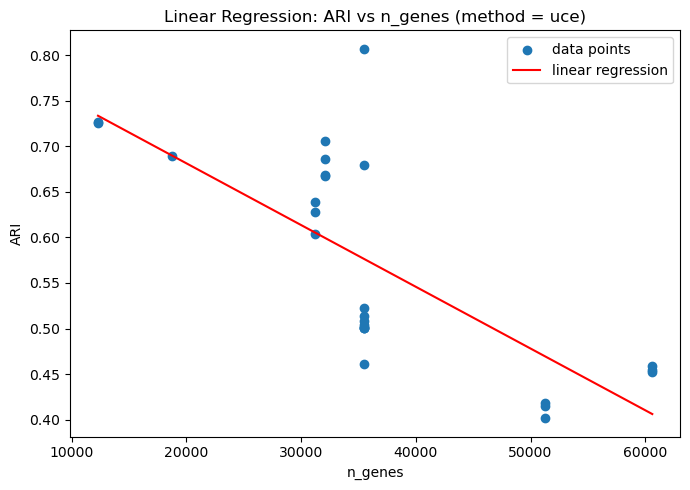

In [71]:
plt.figure(figsize=(7, 5))
plt.scatter(df_uce["n_genes"], df_uce["metric_value"], label="data points")

# Regression line
x_line = np.linspace(df_uce["n_genes"].min(), df_uce["n_genes"].max(), 100)
y_line = model.predict(x_line.reshape(-1, 1))
plt.plot(x_line, y_line, color="red", label="linear regression")

plt.xlabel("n_genes")
plt.ylabel("ARI")
plt.title("Linear Regression: ARI vs n_genes (method = uce)")
plt.legend()
plt.tight_layout()
plt.show()


<Axes: xlabel='n_genes', ylabel='metric_value'>

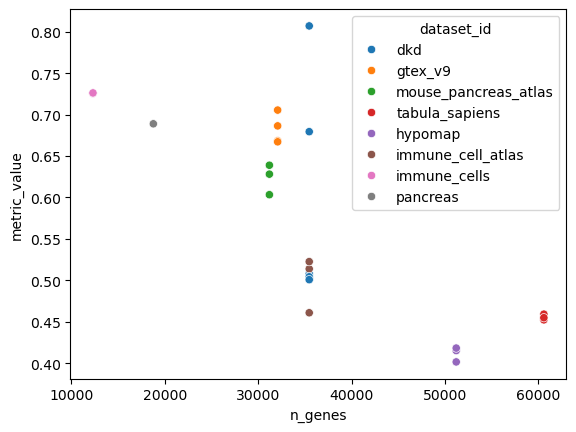

In [82]:
sns.scatterplot(data=df_uce,x="n_genes",y="metric_value", hue="dataset_id")

color by dataset, double check with uce 

you can use seaborn regplot instead of sklearn

but regplot doesn't seem to have a colouring option

wait lmplot has colouring

one trend for one metric&method - look if other metrics show that trend too

lmplot hue=metric

bio metrics vs batch metrics? 